<!-- colab-badge -->
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_02_pytorch_mlp_light.ipynb)

*Open this notebook in Google Colab. Its first code cell fetches the set's library files from the public course repository, so nothing needs uploading.*
*This is the **light** version: every TODO is written out, and you only replace the `...` marked lines with what the comment beside them says.*


<!-- course-header v3 -->

**Deep Learning for Engineering** · MSc, Aalborg University · 2026

Developed by **Remus Teodorescu** (ret@et.aau.dk), with support from Research Assistant **Noman Khan** (nomank@energy.aau.dk).

*Reference text — read for the theory. Used as an **inspirational source** for this course, not as a source of its code:*

- Prince, *Understanding Deep Learning*, MIT Press 2023.

Every notebook in this course has been **written and rewritten by the authors named above**. The code, the problems, the data and the exposition are **original to this course** and are not derived from any publisher's code listings or companion notebooks. Where notation matches a textbook's it is the standard notation of the field, and where an idea is a named author's it is cited as theirs in the text.

See `docs/PROVENANCE.md` for what each reference is cited for, set by set.

---

# Ex_04 · Notebook 02 — The Same Network, in PyTorch

**Deep Learning for Engineering · Aalborg University · Part 1**

You have just solved XOR with nine numbers you chose yourself. This notebook
builds the same network in PyTorch and **finds** those nine numbers instead.

The purpose is to see how much of notebook 01 was mathematics and how much was
bookkeeping. The answer, roughly: the mathematics is four lines and the
bookkeeping was everything else.

Two things have to change before a network of this shape can be trained by
gradient descent, and both are worth understanding rather than accepting.

**The step function has to go.** $\mathrm{step}(z)$ has zero derivative
everywhere it has one at all, so a gradient tells you nothing about how to
change the weights. Replace it with a smooth function of the same general shape.
This notebook uses $\tanh$ in the hidden layer, which is the activation Part 2 of
this course uses throughout, for reasons L4.1 slide 12 gives.

**The error count has to go.** "Two of four rows wrong" is a step function of the
weights as well: nudge a weight and the count either does not change or jumps by
one. Replace it with a smooth loss — here **binary cross entropy**, which is the
right loss for a two-class problem and which L6.1 derives rather than asserts.

What does *not* change is the architecture: two inputs, two hidden neurons, one
output, nine parameters. Same object, different way of finding the numbers.

---

## 0 · Setup

In [5]:
# files-cell v1 ----------------------------------------------------------
# This set's library files must sit beside the notebook. Locally they
# already do. On Google Colab, where a notebook opens on its own, they are
# fetched from the public course repository. Run this cell first.
import os, urllib.request
FILES = ['Ex_4_core.py']
URL = "https://raw.githubusercontent.com/RemusTeodorescu/DL-for-Engineers-Public-Course/main/exercises/Ex04-perceptron-to-mlp/"
for f in FILES:
    if not os.path.exists(f):
        urllib.request.urlretrieve(URL + f, f)
        print("fetched", f)
print("files ready:", ", ".join(FILES))


files ready: Ex_4_core.py


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import Ex_4_core as core

X_np, y_np = core.logic_dataset("XOR")

X = torch.tensor(X_np, dtype=torch.float32)          # shape (4, 2)
y = torch.tensor(y_np, dtype=torch.float32).view(-1, 1)   # shape (4, 1)

print("X:", tuple(X.shape), " y:", tuple(y.shape))
print(X)
print(y.ravel())

X: (4, 2)  y: (4, 1)
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([0., 1., 1., 0.])


**What you should see.** `X: (4, 2)  y: (4, 1)`, then the four input rows and the
targets `[0., 1., 1., 0.]`.

The `view(-1, 1)` matters. PyTorch losses compare tensors of the same shape, and
a target of shape `(4,)` against a prediction of shape `(4, 1)` broadcasts into a
4 × 4 comparison that trains happily and produces nonsense. It is the single most
common silent bug in a first PyTorch model, so it is worth getting a habit early:
**print the shapes**.

---

## 1 · The model

`core.MLP` builds the network you set by hand:

```
input (2)  ->  Linear(2, 2)  ->  Tanh  ->  Linear(2, 1)  ->  output (1)
```

The output is left as a raw number rather than being squashed into $[0, 1]$,
because the loss below expects it that way — `BCEWithLogitsLoss` applies the
sigmoid itself, in a numerically stabler manner than doing it in two steps.

### Your turn

Build the model and check the parameter count against notebook 01.

In [7]:
# TODO 1 --- the 2-2-1 network --------------------------------------------------------
# Two `...` to replace, one per line:
#   model  ->  core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)
#   n_par  ->  core.count_parameters(model)
core.set_seed(0)
model = core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)                                       # <- core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)
n_par = core.count_parameters(model)                                     # <- core.count_parameters(model)
assert not any(v is ... for v in (model, n_par)), "TODO 1: replace the two ..."
# ------------------------------------------------------------------------------

In [8]:
print(model)
print()
print("parameters:", n_par)
for name, p in model.named_parameters():
    print(f"  {name:12s} {tuple(p.shape)}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)

parameters: 9
  net.0.weight (2, 2)
  net.0.bias   (2,)
  net.2.weight (1, 2)
  net.2.bias   (1,)


**What you should see.** The layer stack, then `parameters: 9`, then four named
tensors: `net.0.weight (2, 2)`, `net.0.bias (2,)`, `net.2.weight (1, 2)`,
`net.2.bias (1,)`.

Four weights, two hidden biases, two output weights, one output bias. **Nine** —
the same nine you wrote down by hand, in the same arrangement. Nothing has been
added by using a framework.

---

## 2 · The training loop

Here is the whole of it, and it is the loop you will write for the rest of the
course:

```python
for epoch in range(epochs):
    optimiser.zero_grad()          # forget last step's gradients
    loss = loss_fn(model(X), y)    # forward pass and loss
    loss.backward()                # gradients of the loss w.r.t. every parameter
    optimiser.step()               # one step downhill
```

Four lines. Compare with notebook 01, where you wrote the forward pass, the error,
the update rule for the weights and the update rule for the bias, and where
adding a second layer would have meant deriving and coding the chain rule by
hand. That derivation is what nobody had in 1969, and `loss.backward()` is what
1986 gave the field.

Two of those four lines catch people out.

**`zero_grad`.** PyTorch *accumulates* gradients into `.grad` rather than
replacing them. Forget this line and every step uses the sum of all gradients so
far, which usually looks like a learning rate that grows without bound. It is
deliberate behaviour — it lets you split a batch across several backward passes —
and it is the second most common silent bug in a first PyTorch model.

**`loss.backward()`.** This walks the graph that the forward pass recorded and
fills in $\partial \mathcal{L} / \partial \theta$ for every parameter. You met it
in L2.2. In Part 2 of this course you will call `torch.autograd.grad` to
differentiate with respect to the network's *inputs* instead, and that single
change is the entire mechanism of a physics-informed network.

### Your turn

Write the loop. Use `torch.optim.Adam` with a learning rate of 0.05 and
`nn.BCEWithLogitsLoss`, for 2000 epochs, recording the loss at every epoch.

A correct answer produces a loss that falls from about 0.7 to below 0.01.

In [11]:
# TODO 2 --- the training loop ---------------------------------------------------------
# Four `...` to replace, in this order:
#   line 1  ->  nn.BCEWithLogitsLoss()
#   line 2  ->  torch.optim.Adam(model.parameters(), lr=0.05)
#   line 3  ->  loss_fn(model(X), y)              forward pass and loss, one line
#   line 4  ->  optimiser.zero_grad()             before backward, every epoch
loss_fn   = nn.BCEWithLogitsLoss()                                   # <- nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.05)                                  # <- torch.optim.Adam(model.parameters(), lr=0.05)
losses    = []

for epoch in range(2000):
    loss = loss_fn(model(X), y)
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()
    losses.append(float(loss.item()))
# ------------------------------------------------------------------------------

loss at epoch    0: 0.7152
loss at epoch 1999: 0.000189

  x1  x2   target   probability   predicted
  0   0      0          0.000          0
  0   1      1          1.000          1
  1   0      1          1.000          1
  1   1      0          0.000          0

4 of 4 correct


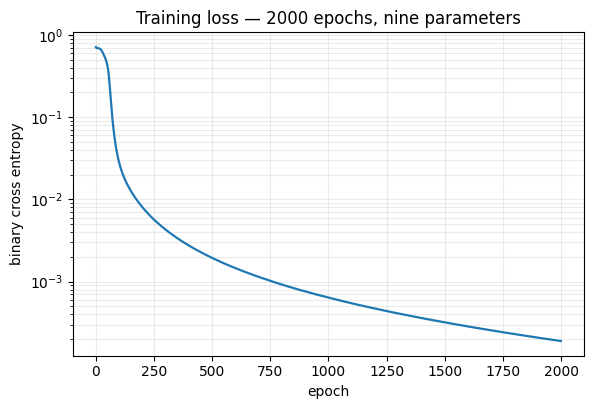

In [12]:
with torch.no_grad():
    logits = model(X)
    probabilities = torch.sigmoid(logits).numpy().ravel()
predicted = (probabilities > 0.5).astype(float)

print(f"loss at epoch    0: {losses[0]:.4f}")
print(f"loss at epoch 1999: {losses[-1]:.6f}")
print()
print("  x1  x2   target   probability   predicted")
for i in range(4):
    print(f"  {X_np[i,0]:.0f}   {X_np[i,1]:.0f}      {y_np[i]:.0f}"
          f"          {probabilities[i]:.3f}          {predicted[i]:.0f}")
print(f"\n{int((predicted == y_np).sum())} of 4 correct")

fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.plot(losses, lw=1.6, color="#1f77b4")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("binary cross entropy")
ax.set_title("Training loss — 2000 epochs, nine parameters")
ax.grid(alpha=0.25, which="both")
plt.show()

**What you should see — one of two things.**

**Either** a loss that starts near 0.7 and ends below 0.01, with all four rows
correct and probabilities close to 0 and 1. That is a converged run.

**Or** a loss that falls to somewhere around 0.35 and then flattens, with two or
three rows correct and at least one probability sitting at almost exactly 0.5.
That is a *stuck* run, and it is not a bug in your loop.

Which of the two you get depends on the random initialisation, and therefore on
your PyTorch version. Do not fix it if you got the second one; section 3 is
entirely about it, and being able to recognise a stuck run from its loss curve is
worth more than a converged run on the first try.

Either way, look at the loss curve. It is smooth, monotone and utterly
unremarkable in both cases — which is the point being made.

---

## 3 · The part that is not in the textbooks

A network with two hidden neurons solving XOR is the smallest interesting model
there is, and it does not always work. Gradient descent finds a *local* minimum
of the loss, and this problem has bad ones: configurations where three rows are
right, the fourth is wrong, and every small change to the weights makes the loss
worse.

This is not a defect of PyTorch or of your loop. It is a property of the
optimisation problem, and the standard remedy in practice is embarrassingly
simple: **try again from a different initialisation**.

### Your turn

Train the same architecture from ten different seeds and count how many succeed.

For each seed: `core.set_seed(seed)`, build a fresh model, train it for 2000
epochs exactly as above, and record the final loss and the number of correct
rows.

A correct answer prints a table of ten rows in which most, but not all, get 4 of
4.

In [13]:
# TODO 3 --- ten seeds ------------------------------------------------------------------
# Three `...` to replace, all inside the loop:
#   line 1  ->  core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)   a FRESH model
#   line 2  ->  loss_fn(model(X), y)
#   line 3  ->  int((predicted == y_np).sum())                             rows correct
results = []
for seed in range(10):
    core.set_seed(seed)
    model = core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)                                   # <- core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)
    loss_fn = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.05)
    for epoch in range(2000):
        loss = loss_fn(model(X), y)                                # <- loss_fn(model(X), y)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
    with torch.no_grad():
        predicted = (torch.sigmoid(model(X)).numpy().ravel() > 0.5).astype(float)
    n_correct = int((predicted == y_np).sum())                               # <- int((predicted == y_np).sum())
    results.append((seed, float(loss.item()), n_correct))
# ------------------------------------------------------------------------------

In [14]:
print(" seed   final loss   rows correct")
for seed, final_loss, n_correct in results:
    flag = "" if n_correct == 4 else "   <-- stuck"
    print(f" {seed:4d}   {final_loss:10.5f}   {n_correct:6d}{flag}")

n_solved = sum(1 for _, _, n in results if n == 4)
print(f"\n{n_solved} of 10 seeds solved XOR")

 seed   final loss   rows correct
    0      0.00019        4
    1      0.34662        3   <-- stuck
    2      0.00020        4
    3      0.00025        4
    4      0.00029        4
    5      0.34663        2   <-- stuck
    6      0.34663        2   <-- stuck
    7      0.47743        3   <-- stuck
    8      0.34663        2   <-- stuck
    9      0.34663        2   <-- stuck

4 of 10 seeds solved XOR


**What you should see.** Some seeds reaching a loss below 0.01 with 4 of 4
correct, and others stuck at a loss near 0.35 with 2 or 3 rows correct. Anything
from about five to nine successes out of ten is normal. The exact count depends
on your PyTorch version and does not matter; what matters is that **it is not ten
out of ten**.

Three things follow, and all three are worth writing in your report.

**A single run is not evidence.** If you had drawn seed 0 and it worked, you
would have concluded that this always works. If you had drawn a bad one, you
might have concluded that your loop was broken. Neither conclusion is available
from one run, and the habit of running several seeds is cheap insurance.

**The stuck runs are stuck at a sensible-looking loss.** Nothing prints an error.
The loss curve falls smoothly and then flattens, exactly as a converged run does.
This is the general shape of failure in machine learning: not a crash, but a
plausible number.

**Capacity is the usual cure.** Two hidden neurons is the theoretical minimum for
XOR, and minimal models are the ones most easily trapped. Try `hidden=(8,)` — 25
parameters instead of 9 — and the failures largely disappear. That is a first
example of a phenomenon L4.2 comes back to: extra capacity often makes
optimisation *easier*, which is a separate question from whether it makes
generalisation worse.

---

## 3b · One that worked

Take the best seed from your table, retrain it, and look at what the network
computes. This is the figure notebook 01 earned.

using seed 2
XOR, trained:
  x1  x2   target   predicted
  0   0      0         0 
  0   1      1         1 
  1   0      1         1 
  1   1      0         0 
  4 of 4 correct


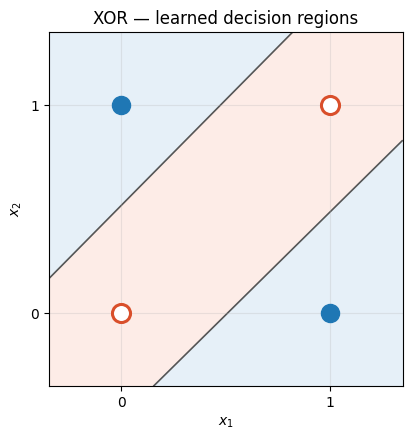

In [17]:
solved = [r for r in results if r[2] == 4]
if not solved:
    raise RuntimeError("no seed solved XOR — try lr=0.1, or 4000 epochs")
best_seed = 2 #min(solved, key=lambda r: r[1])[0]
print("using seed", best_seed)

core.set_seed(best_seed)
model_ok = core.MLP(hidden=(2,), activation="tanh", n_in=2, n_out=1)
loss_fn = nn.BCEWithLogitsLoss()
optimiser = torch.optim.Adam(model_ok.parameters(), lr=0.05)
for epoch in range(2000):
    optimiser.zero_grad()
    loss = loss_fn(model_ok(X), y)
    loss.backward()
    optimiser.step()

with torch.no_grad():
    p_ok = torch.sigmoid(model_ok(X)).numpy().ravel()
core.truth_table((p_ok > 0.5).astype(float), y_np, "XOR, trained:")

def torch_predict(G):
    with torch.no_grad():
        return torch.sigmoid(model_ok(torch.tensor(G, dtype=torch.float32))).numpy().ravel()

fig, ax = plt.subplots(figsize=(5.0, 4.6))
core.plot_logic(X_np, y_np, ax=ax, title="XOR — learned decision regions")
core.plot_boundary(ax, torch_predict)
plt.show()

**What you should see.** Four correct rows and a plot in which a **curved band**
separates the two filled markers from the two hollow ones.

Compare that band with the hand-built network in notebook 01, section 7. There
the boundary was two straight pieces meeting at a corner, because the hidden
neurons were step functions. Here it is smooth, because they are $\tanh$. The two
networks solve the problem by the same construction — two lines, then a decision
about them — and differ only in the sharpness of the transition.

Nine parameters, found rather than chosen. That is the whole of notebook 02.

---

## 4 · What PyTorch actually replaced

Fill this table in for yourself as you read it — it is the summary the report
wants.

| | notebook 01, NumPy | notebook 02, PyTorch |
| --- | --- | --- |
| forward pass | written by hand | written by hand (`model(X)`) |
| activation | `step` | `tanh` |
| loss | count of wrong rows | binary cross entropy |
| gradients | none — a special-purpose update rule | `loss.backward()` |
| parameter update | two lines you wrote | `optimiser.step()` |
| adding a second hidden layer | derive the chain rule yourself | one more line in `hidden=(...)` |
| parameters | 9, set by hand | 9, found by gradient descent |

The row that matters is the second to last. Everything in notebook 01 was
specific to a single layer of step neurons; nothing in it generalised. The moment
gradients are available, depth costs nothing to *write*, and the rest of this
course is about what depth costs in every other sense.

---

## 5 · Before you move on

Answer these here.

1. `BCEWithLogitsLoss` was used instead of counting wrong rows. Name the property
   the count lacks, and name one thing the cross entropy tells you that the count
   does not.
2. In notebook 01 you set nine numbers that solved XOR exactly. Gradient descent
   found nine different numbers. Are they equivalent? What does that suggest
   about interpreting the weights of a trained network?
3. One or more of your seeds got stuck. Given only the training loss curve of a
   stuck run — not the accuracy — how would you tell it apart from a converged
   run? (Look at the numbers in your table before answering.)
4. You now have two implementations of the same model. Which would you use to
   convince a sceptical colleague that the network is doing what you claim, and
   why?

*Write your answers here.*

1.
2.
3.
4.

---

Continue with **[`Ex04_03_counting_kinks_light.ipynb`](https://colab.research.google.com/github/RemusTeodorescu/DL-for-Engineers-Public-Course/blob/main/exercises/Ex04-perceptron-to-mlp/Ex04_03_counting_kinks_light.ipynb)**, which leaves classification
behind and looks at what a network's output actually looks like as a function.